# V1.5 — Spectral Skill: PSD Plots and Resolved Scale

This tutorial walks through the four PSD visualisation panels in
`xr_toolz.viz.validation`:

- `PSDIsotropicPanel` — log-log isotropic (radially-averaged) PSD vs
  wavenumber, with a twin wavelength axis.
- `PSDIsotropicScorePanel` — isotropic PSD score vs wavenumber, with
  the **resolved scale** (wavelength where score crosses 0.5)
  annotated.
- `PSDSpaceTimePanel` — 2-D space-time PSD as a log-norm contour,
  with twin wavelength / period axes.
- `PSDSpaceTimeScorePanel` — 2-D space-time score with the 0.5
  threshold contour overlaid.

We compare three SSH fields over the **North Atlantic basin** for
Q2 2023 (1 April – 30 June, 91 days — long enough to give the
space-time PSD a reasonable frequency resolution):

1. **GLORYS12 reanalysis** (`zos`) — eddy-permitting model output at
   1/12°, the reference truth.
2. **CMEMS DUACS L4** (`adt`) — gridded multi-altimeter SSH at 1/8°,
   the standard altimetry product.
3. **Smoothed twin** — GLORYS gaussian-smoothed (σ=2 cells) as a
   deliberately-blurred baseline.

### Reference

The DUACS L4 effective spatial resolution is documented in
**Ballarotta et al. (2019)**, *On the resolutions of ocean altimetry
maps*, Ocean Science 15, 1091–1109,
<https://os.copernicus.org/articles/15/1091/2019/>. They report
~200 km at midlatitude with **larger values in high-variability
regions** like the Gulf Stream and Kuroshio. We expect our basin-mean
resolved scale to land in the same band.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage as ndi
import xarray as xr

from xr_toolz.core import Graph, Input, Sequential, Signature
from xr_toolz.geo.operators import RemoveMean
from xr_toolz.interpolate.operators import RegridLike
from xr_toolz.metrics import PSDScore, psd_score
from xr_toolz.transforms import power_spectrum
from xr_toolz.transforms.operators import TimeRescale
from xr_toolz.viz.validation import (
    PSDIsotropicPanel,
    PSDIsotropicScorePanel,
    PSDSpaceTimePanel,
    PSDSpaceTimeScorePanel,
)


warnings.filterwarnings("ignore")

## 1. Load the cached North Atlantic data

We use 91 days of Q2 2023 (Apr–Jun) over the North Atlantic basin
(10–65°N, 80°W–0°). The data are pulled once from CMEMS via
`copernicusmarine` and cached locally — see the rebuild snippet
below. The cache file is gitignored.

In [2]:
CACHE = Path("../../.cache")
glorys = xr.open_dataset(CACHE / "glorys12_north_atlantic_2023Q2.nc")["zos"]
duacs = xr.open_dataset(CACHE / "duacs_north_atlantic_2023Q2.nc")["adt"]
print("GLORYS:", dict(glorys.sizes))
print("DUACS :", dict(duacs.sizes))

GLORYS: {'time': 91, 'latitude': 661, 'longitude': 961}
DUACS : {'time': 91, 'latitude': 440, 'longitude': 640}


**Rebuild the cache** (only needed if `.cache/*.nc` is missing):

```python
import copernicusmarine as cm

NA = dict(
    minimum_longitude=-80.0, maximum_longitude=0.0,
    minimum_latitude=10.0, maximum_latitude=65.0,
    start_datetime="2023-04-01", end_datetime="2023-06-30",
)
cm.open_dataset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
    variables=["zos"], **NA,
).to_netcdf(".cache/glorys12_north_atlantic_2023Q2.nc")
cm.open_dataset(
    dataset_id="cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D",
    variables=["adt"], **NA,
).to_netcdf(".cache/duacs_north_atlantic_2023Q2.nc")
```

## 2. Snapshot of the SSH fields

A quick look so we know what we're working with. GLORYS shows
fine-scale eddies, DUACS is smoother (band-limited L4).

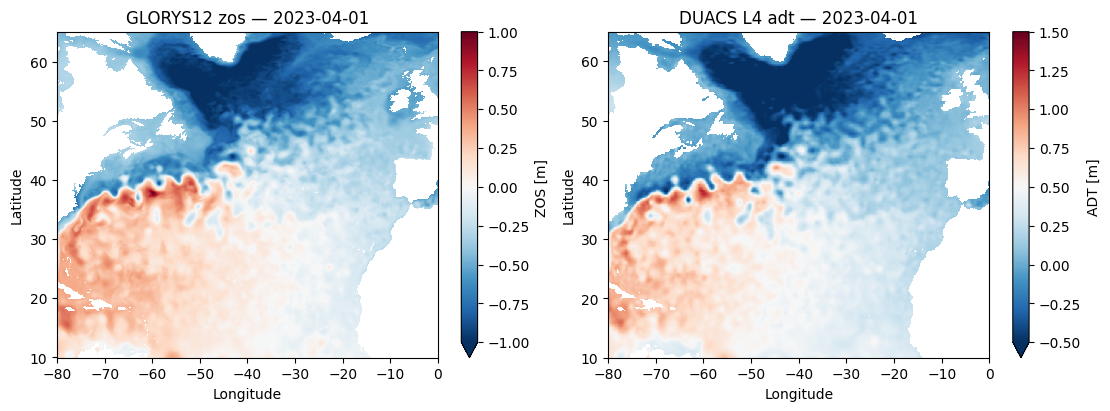

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
g0 = glorys.isel(time=0)
d0 = duacs.isel(time=0)
g0.plot(ax=axes[0], cmap="RdBu_r", vmin=-1.0, vmax=1.0, cbar_kwargs={"label": "ZOS [m]"})
axes[0].set_title("GLORYS12 zos — 2023-04-01")
d0.plot(ax=axes[1], cmap="RdBu_r", vmin=-0.5, vmax=1.5, cbar_kwargs={"label": "ADT [m]"})
axes[1].set_title("DUACS L4 adt — 2023-04-01")
for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
plt.show()

## 3. Data prep — built from xr_toolz operators

Three things to do before computing PSDs, each handled by an
existing `Operator`:

1. **Common grid**: GLORYS lives on 1/12°, DUACS on 1/8°.
   [`RegridLike(target=duacs, dims=("lat","lon"))`][regrid] resamples
   GLORYS onto the DUACS grid bilinearly.
2. **Numeric time coord**: `xrft` reads `datetime64[ns]` as
   nanoseconds, so `freq_time` would come out in cycles/ns.
   [`TimeRescale(freq_dt=1.0, freq_unit="D")`][trescale] rewrites
   `time` as days-from-start.
3. **Spatial-mean anomaly**: ZOS and ADT are both SSH-like in metres
   but referenced differently (DUACS includes MDT). Subtracting the
   per-snapshot **spatial mean** strips the static MDT-like offset
   while preserving spatial structure —
   [`RemoveMean(("lat","lon"))`][rmean] does this.

[regrid]: ../api/reference.md
[trescale]: ../api/reference.md
[rmean]: ../api/reference.md

Operators take Datasets, so we wrap each DataArray as a single-var
`xr.Dataset` first. We also define a tiny `FillNaN` op to zero out
land cells after spatial-mean removal — `xr_toolz` doesn't ship a
generic constant-fill op, but extending the framework is two lines.

In [4]:
from typing import Any

from xr_toolz.core import Operator


class FillNaN(Operator):
    """Replace NaN with a constant (default 0.0). Land cells become 0
    after spatial-mean removal so they contribute no spectral energy."""

    def __init__(self, value: float = 0.0) -> None:
        self.value = float(value)

    def _apply(self, ds: xr.Dataset) -> xr.Dataset:
        return ds.fillna(self.value)

    def get_config(self) -> dict[str, Any]:
        return {"value": self.value}


glorys_ds = glorys.rename({"latitude": "lat", "longitude": "lon"}).to_dataset(name="zos")
duacs_ds = duacs.rename({"latitude": "lat", "longitude": "lon"}).to_dataset(name="zos")

# Reusable prep pipelines — applied to both GLORYS and DUACS. GLORYS
# additionally needs a regrid step to land on the DUACS grid, so it
# gets a longer pipeline.
prep_glorys = Sequential(
    [
        RegridLike(target=duacs_ds, dims=("lat", "lon")),
        TimeRescale(freq_dt=1.0, freq_unit="D"),
        RemoveMean(dims=("lat", "lon")),
        FillNaN(0.0),
    ]
)
prep_duacs = Sequential(
    [
        TimeRescale(freq_dt=1.0, freq_unit="D"),
        RemoveMean(dims=("lat", "lon")),
        FillNaN(0.0),
    ]
)
# describe() shows operator structure; summary() threads a Signature
# through each step to show how dims evolve.
print("GLORYS prep pipeline (structure + shapes):")
print(prep_glorys.describe())
print()
glorys_signature = Signature(
    dict(glorys_ds.sizes), dtype=str(glorys_ds["zos"].dtype),
)
print(prep_glorys.summary(glorys_signature))
print()
print("DUACS prep pipeline (structure + shapes):")
print(prep_duacs.describe())
print()
duacs_signature = Signature(
    dict(duacs_ds.sizes), dtype=str(duacs_ds["zos"].dtype),
)
print(prep_duacs.summary(duacs_signature))

glorys_a = prep_glorys(glorys_ds)["zos"]
duacs_a = prep_duacs(duacs_ds)["zos"]

GLORYS prep pipeline (structure + shapes):
Sequential (4 ops)
├── RegridLike(target_shape={'lat': 440, 'lon': 640},
│              dims=['lat', 'lon'],
│              method='linear')
├── TimeRescale(freq_dt=1.0, freq_unit='D', t0=None, time='time')
├── RemoveMean(dims=['lat', 'lon'])
└── FillNaN(value=0.0)

Sequential (4 ops)
Step  Operator                                                                                 Input Signature                             Output Signature                          
----  ---------------------------------------------------------------------------------------  ------------------------------------------  ------------------------------------------
0     RegridLike(target_shape={'lat': 440, 'lon': 640}, dims=['lat', 'lon'], method='linear')  (lat=661, lon=961, time=91); dtype=float64  (lat=440, lon=640, time=91); dtype=float64
1     TimeRescale(freq_dt=1.0, freq_unit='D', t0=None, time='time')                            (lat=440, lon=640, time=91); d

### Smoothed-twin baseline

To have a **known-good** comparison curve (something we expect to be
close to GLORYS at large scales but degrade at small scales), we
build a Gaussian-smoothed copy of the prepped GLORYS.

In [5]:
smooth_a = xr.apply_ufunc(
    lambda a: ndi.gaussian_filter(a, sigma=(0, 2.0, 2.0)),
    glorys_a,
).rename("zos")

## 4. Isotropic PSD — `PSDIsotropicPanel`

The radially-averaged PSD over `(lon, lat)`, time-averaged. All three
fields overlap at large scales; DUACS rolls off steeper than GLORYS
at high wavenumbers (band-limited altimetry); the smoothed twin rolls
off even more steeply (gaussian filter).

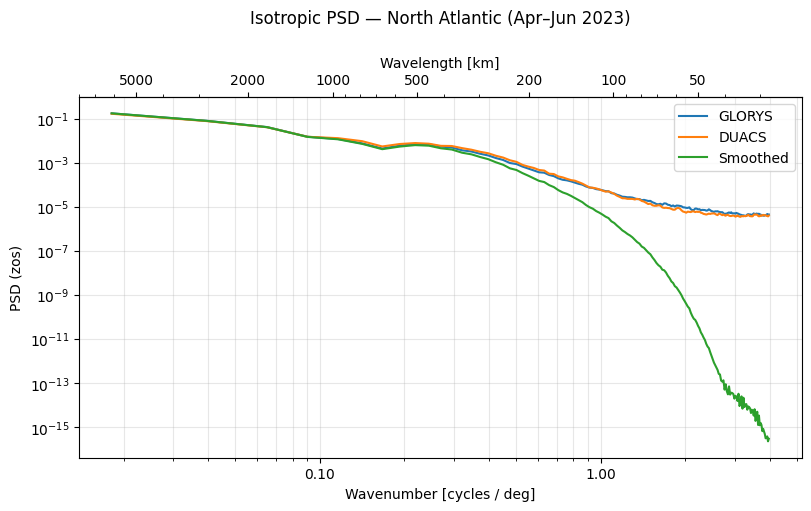

In [6]:
DEG_TO_KM = 1.0 / 111.0  # cycles/deg → cycles/km

iso_g = power_spectrum(glorys_a, dim=("lon", "lat"), isotropic=True).mean("time")
iso_d = power_spectrum(duacs_a, dim=("lon", "lat"), isotropic=True).mean("time")
iso_s = power_spectrum(smooth_a, dim=("lon", "lat"), isotropic=True).mean("time")

iso_ds = xr.Dataset({"GLORYS": iso_g, "DUACS": iso_d, "Smoothed": iso_s})

panel = PSDIsotropicPanel(
    freq_dim="freq_r",
    space_scale=DEG_TO_KM,
    wavelength_label="Wavelength [km]",
    wavenumber_label="Wavenumber [cycles / deg]",
    ylabel="PSD (zos)",
    figsize=(8, 5),
    title="Isotropic PSD — North Atlantic (Apr–Jun 2023)",
)
fig = panel(iso_ds)
plt.show()

## 5. Isotropic PSD score — `PSDIsotropicScorePanel`

The score is `1 - PSD(pred − ref) / PSD(ref)`. A score of 1 means
the prediction reproduces the reference's spectrum exactly at that
scale; 0.5 is the conventional **resolved threshold** — the panel
annotates the wavelength where the score first crosses 0.5.

**Display convention**: scores below 0 (where `PSD(error) > PSD(ref)`)
are clipped to 0 in the plot, since their precise negative value
isn't informative once the field is "unresolved" (matches the
convention in Ballarotta et al. 2019).

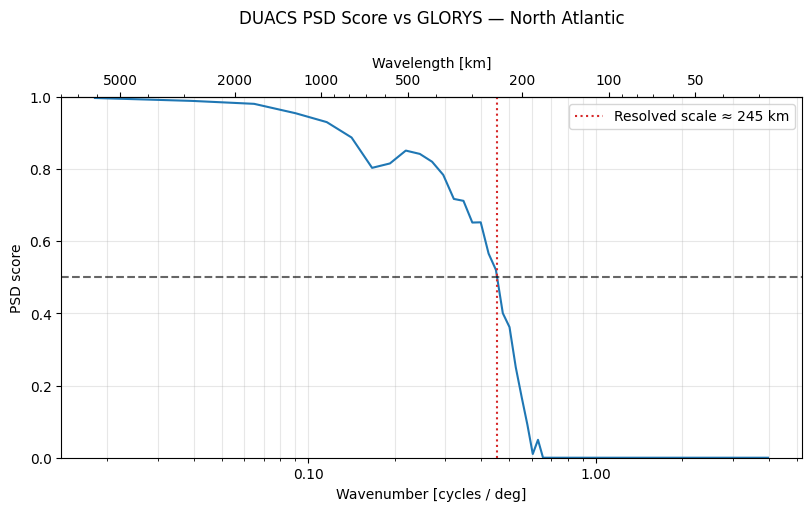

In [7]:
score_d = psd_score(
    duacs_a.to_dataset(name="zos"),
    glorys_a.to_dataset(name="zos"),
    "zos",
    psd_dims=("lon", "lat"),
    isotropic=True,
).mean("time")

panel = PSDIsotropicScorePanel(
    freq_dim="freq_r",
    space_scale=DEG_TO_KM,
    wavelength_label="Wavelength [km]",
    wavenumber_label="Wavenumber [cycles / deg]",
    figsize=(8, 5),
    title="DUACS PSD Score vs GLORYS — North Atlantic",
)
fig = panel(score_d)
plt.show()

The resolved scale lands in the **200–300 km band** that
[Ballarotta et al. (2019)](https://os.copernicus.org/articles/15/1091/2019/)
document for DUACS L4 at midlatitude — slightly larger than the
global-mean ~200 km because the North Atlantic includes the
eddy-rich Gulf Stream system, where altimetry resolution is
inherently coarser.

### Smoothed-twin score for comparison

Same panel, applied to the gaussian-smoothed baseline. The score
curve has the same characteristic shape — high at large scales,
crossing 0.5 at the smoother's effective resolution.

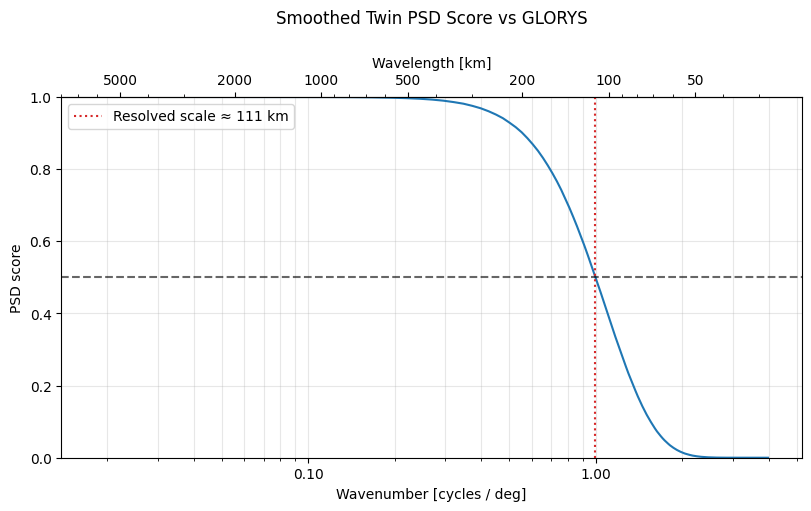

In [8]:
score_s = psd_score(
    smooth_a.to_dataset(name="zos"),
    glorys_a.to_dataset(name="zos"),
    "zos",
    psd_dims=("lon", "lat"),
    isotropic=True,
).mean("time")

panel = PSDIsotropicScorePanel(
    freq_dim="freq_r",
    space_scale=DEG_TO_KM,
    wavelength_label="Wavelength [km]",
    wavenumber_label="Wavenumber [cycles / deg]",
    figsize=(8, 5),
    title="Smoothed Twin PSD Score vs GLORYS",
)
fig = panel(score_s)
plt.show()

## 6. Space-time PSD — `PSDSpaceTimePanel`

2-D PSD over `(lon, time)`, latitude-averaged. Reads as a basin-mean
energy distribution across **zonal wavenumber × frequency**.
Twin axes show wavelength (km) and period (days).

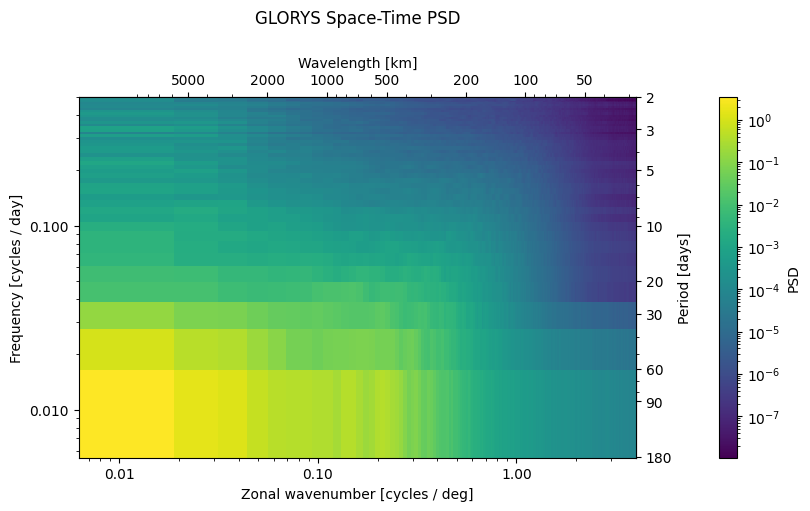

In [9]:
st_g = power_spectrum(glorys_a, dim=("lon", "time")).mean("lat")

panel = PSDSpaceTimePanel(
    freq_space_dim="freq_lon",
    freq_time_dim="freq_time",
    space_scale=DEG_TO_KM,
    time_scale=1.0,
    wavelength_label="Wavelength [km]",
    period_label="Period [days]",
    wavenumber_label="Zonal wavenumber [cycles / deg]",
    frequency_label="Frequency [cycles / day]",
    figsize=(8, 5),
    title="GLORYS Space-Time PSD",
    cmap="viridis",
)
fig = panel(st_g)
plt.show()

## 7. Space-time PSD score — `PSDSpaceTimeScorePanel`

The 2-D score with the **0.5 threshold contour** overlaid as a black
line. Green = resolved, red = unresolved. The contour cleanly
separates the basin's resolvable region from the unresolved tail.

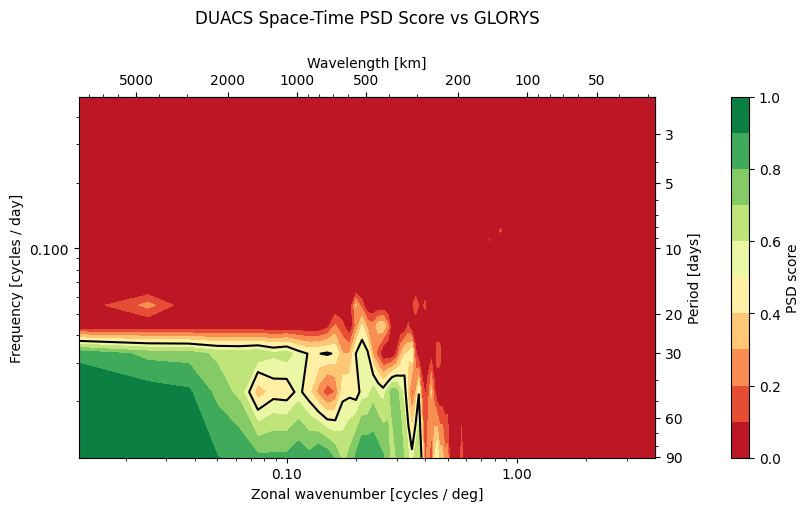

In [10]:
score_st_d = psd_score(
    duacs_a.to_dataset(name="zos"),
    glorys_a.to_dataset(name="zos"),
    "zos",
    psd_dims=("lon", "time"),
    avg_dims=("lat",),
    isotropic=False,
)

panel = PSDSpaceTimeScorePanel(
    freq_space_dim="freq_lon",
    freq_time_dim="freq_time",
    space_scale=DEG_TO_KM,
    time_scale=1.0,
    wavelength_label="Wavelength [km]",
    period_label="Period [days]",
    wavenumber_label="Zonal wavenumber [cycles / deg]",
    frequency_label="Frequency [cycles / day]",
    figsize=(8, 5),
    title="DUACS Space-Time PSD Score vs GLORYS",
)
fig = panel(score_st_d)
plt.show()

## 8. Bonus — full pipeline from raw cache to figure

Everything in this notebook is composable. Below we build a single
`Graph` DAG that takes the **raw GLORYS and DUACS Datasets** and
returns a rendered Figure — chaining the prep `Sequential`s defined
earlier, the two-input `PSDScore`, a tiny inline time-mean op, and
the `PSDIsotropicScorePanel` terminal.

This mirrors how a benchmarking script would be structured: the
graph captures the entire transformation from on-disk cache to plot,
and the same DAG applies to a different region or model with no code
changes.

In [11]:
class MeanOverDim(Operator):
    """Tiny custom Operator: average a Dataset over the given dim."""

    def __init__(self, dim: str) -> None:
        self.dim = dim

    def _apply(self, ds: xr.Dataset) -> xr.Dataset:
        return ds.mean(self.dim)

    def get_config(self) -> dict[str, Any]:
        return {"dim": self.dim}


# Inputs to the DAG: the raw Datasets we loaded from cache.
glorys_raw = glorys.rename({"latitude": "lat", "longitude": "lon"}).to_dataset(name="zos")
duacs_raw = duacs.rename({"latitude": "lat", "longitude": "lon"}).to_dataset(name="zos")

g_in = Input(name="glorys_raw")
d_in = Input(name="duacs_raw")

# Reuse the prep pipelines defined in section 3.
g_prepped = prep_glorys(g_in)
d_prepped = prep_duacs(d_in)

score = PSDScore("zos", psd_dims=("lon", "lat"), isotropic=True)(d_prepped, g_prepped)
score_avg = MeanOverDim("time")(score)
fig_node = PSDIsotropicScorePanel(
    freq_dim="freq_r",
    space_scale=DEG_TO_KM,
    wavelength_label="Wavelength [km]",
    wavenumber_label="Wavenumber [cycles / deg]",
    figsize=(8, 5),
    title="End-to-End Graph: raw → prep → PSDScore → mean → panel",
)(score_avg)

graph = Graph(
    inputs={"glorys_raw": g_in, "duacs_raw": d_in},
    outputs={"figure": fig_node, "score": score_avg},
)
print(graph)

Graph(inputs=['glorys_raw', 'duacs_raw'], outputs=['figure', 'score'])


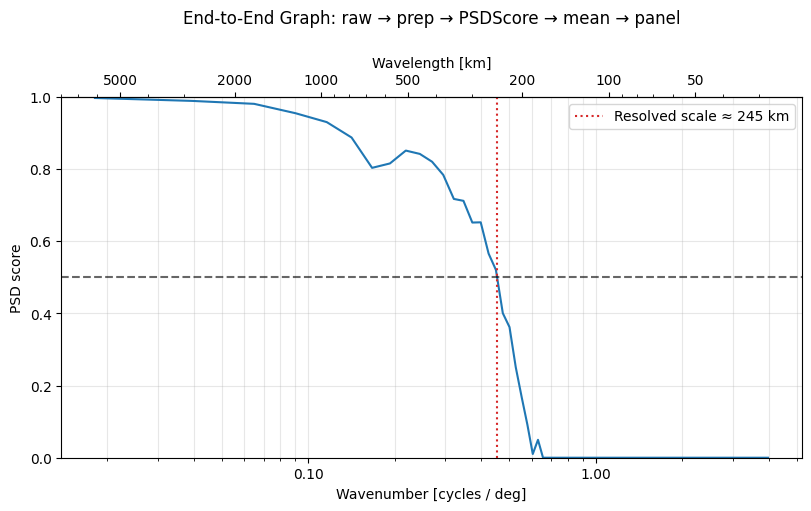

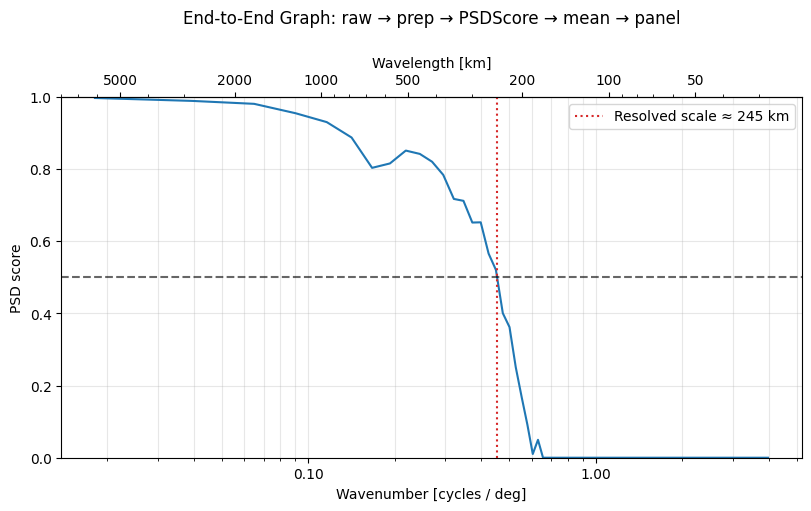

In [12]:
from IPython.display import display


out = graph(glorys_raw=glorys_raw, duacs_raw=duacs_raw)
display(out["figure"])

The `score` Dataset is also exposed as an output, so downstream
consumers (a CSV dump, a `Tap` for logging, another panel) can
attach to the same DAG without re-running the upstream prep + PSD
computation.

In [13]:
print(out["score"])

<xarray.Dataset> Size: 2kB
Dimensions:  (freq_r: 155)
Coordinates:
  * freq_r   (freq_r) float64 1kB 0.01815 0.03947 0.06492 ... 3.921 3.947 3.973
Data variables:
    score    (freq_r) float64 1kB 0.9971 0.989 0.9809 ... -1.094 -1.014 -1.107


## Summary

| Panel | Inputs | Use |
|-------|--------|-----|
| `PSDIsotropicPanel` | `power_spectrum(..., isotropic=True)` | Compare PSDs across products |
| `PSDIsotropicScorePanel` | `psd_score(..., isotropic=True)` | Resolved-scale diagnostic |
| `PSDSpaceTimePanel` | `power_spectrum(..., dim=("lon","time"))` | Energy distribution in (k, ω) |
| `PSDSpaceTimeScorePanel` | `psd_score(..., psd_dims=("lon","time"))` | Resolved region in (k, ω) |

**Reference**:
Ballarotta, M., Ubelmann, C., Pujol, M.-I., et al. (2019).
*On the resolutions of ocean altimetry maps*, Ocean Science 15,
1091–1109. <https://os.copernicus.org/articles/15/1091/2019/>